### SparseDPC Policy Training & Pruning Pipeline

This notebook outlines the SparseDPC workflow for training sparse, interpretable control policies. The process begins with **training a SINDy model for system identification**, capturing the dynamics from data using symbolic regression.

Key steps:

- **System ID:** Fit a SINDy model to identify system dynamics using a polynomial or Fourier library.
- **Policy Modeling:** Use the identified dynamics as the base for constructing symbolic policy models.
- **Training:** Train policies via differentiable optimization using Neuromancer's `SparseTrainer`.
- **Pruning:** Iteratively prune insignificant terms based on learned coefficients to simplify expressions.
- **Logging:** Track metrics and active terms with a custom logger for interpretability and reproducibility.

The result is a sparse, symbolic policy that is data-driven and control-ready.


#### If you are using Colab, you need to first install the package.

In [1]:
# IF you are using Colab:
#!pip install git+https://github.com/Alirezad126/SparseDPC.git@new

### 📦 Imports and Environment Setup


In [1]:
import torch.nn as nn
import os
import copy
import torch
import numpy as np
import wandb
from datetime import datetime
import matplotlib.pyplot as plt
import copy
import os, json, numpy as np, torch
from pathlib import Path

# Neuromancer imports: modeling, loss, logging, system dynamics
from neuromancer.loggers import BasicLogger
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import ode, integrators
from neuromancer.plot import pltCL, pltPhase

# SparseDPC-specific modules: libraries, data, training, utils
from SparseDPC.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.data.getdata import get_data, get_policy_data
from SparseDPC.trainer.trainer import SparseTrainer
from SparseDPC.utils.integrator import OneElementEulerIntegrator, FullStateEulerIntegrator
from SparseDPC.utils.utils import map_to_new_fx, save_model_with_timestamp
from SparseDPC.utils.loggers import CustomLogger
from SparseDPC.trainer.problem import SparsePolicyBuilder, SparseDynamicsBuilder
from SparseDPC.sindy.fx_library import fx_policy_library
from SparseDPC.utils.utils       import map_to_new_fx, save_model_with_timestamp

# Set random seed for reproducibility
torch.manual_seed(0)

# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


## ⚙️ Training System ID with SINDy


### ⚙️ Define Ground Truth System and Problem Parameters



In [2]:
# Ground truth system model
gt_model = psl.nonautonomous.TwoTank()

# Sampling rate
ts = gt_model.params[1]['ts']

# Problem dimensions
nx = gt_model.nx      # number of states
nu = gt_model.nu      # number of control inputs
nref = nx             # reference dimensions equal to state dimensions

# Constraint bounds
umin = 0.
umax = 1.
xmin = 0.
xmax = 1


### 🧠 Generate Candidate Sparse Dynamics Models

This cell creates a list of candidate sparse dynamic models for each state dimension using `fx_library`, and prints them for inspection. Each model is configured with the same number of states, inputs, and device.


In [3]:
# Create one fx model per state dimension
fx_models = [fx_library(i, nx=nx, nu=nu, seed=0, device=device) for i in range(nx)]

# Print model structures
for fx in fx_models:
    print(fx)


dx0/dt = -0.004*x0 + 0.268*x1 + -0.412*x0^2 + -0.368*x0*x1 + -0.193*x1^2 + 0.134*u_0 + -0.010*u_1 + 0.396*u_0*u_1 + -0.044*x0*u_0 + 0.132*x1*u_0 + -0.151*x0*u_1 + -0.098*x1*u_1 + -0.478*sqrt(x0) + -0.331*sqrt(x1)

dx1/dt = -0.004*x1 + 0.268*x0 + -0.412*x0^2 + -0.368*x0*x1 + -0.193*x1^2 + 0.134*u_0 + -0.010*u_1 + 0.396*u_0*u_1 + -0.044*x0*u_0 + 0.132*x1*u_0 + -0.151*x0*u_1 + -0.098*x1*u_1 + -0.478*sqrt(x0) + -0.331*sqrt(x1)



### 📊 Get data

Gets training, dev, and test datasets using the ground truth model.


In [4]:
nsim = 2000   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 200     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

### 🔁 Train SINDy for System ID

Trains a sparse model for each state using one-step loss.
High `epochs` and `prune_every` allow convergence before pruning.
- `threshold`: sparsity cutoff for pruning small weights
- `threshold_mult`: increasing the threshold after prunning, as coefficient of the remaining terms will grow after prunning other unimportant terms


In [5]:
dyn_cfg = {
    # ---------- loss weights ----------
    "onestep_coef"   : 1.0,      # 1-step prediction error
    "ref_coef"       : 2.0,      # full-horizon (n-step) error
    "l1_coef"        : 3e-6,     # L¹ sparsity on SINDy coefficients

    # ---------- optimiser / schedule ----------
    "lr"             : 2e-3,     # AdamW learning-rate
    "epochs"         : 15999,   # gradient steps per coordinate model

    # ---------- pruning & early-stop ----------
    "threshold"      : 5e-3,     # initial coefficient cutoff
    "prune_every"    : 2000,    # epochs between pruning passes
    "threshold_mult" : 1.09,     # threshold ← threshold × multiplier
    "prune_noise"    : 0.05,     # std-dev of regrowth noise (0 ⇒ none)

    # ---------- training conveniences ----------
    "warmup"         : 300,      # epochs before enabling pruning
    "patience"       : 50,       # early-stop patience on dev_loss
}


None


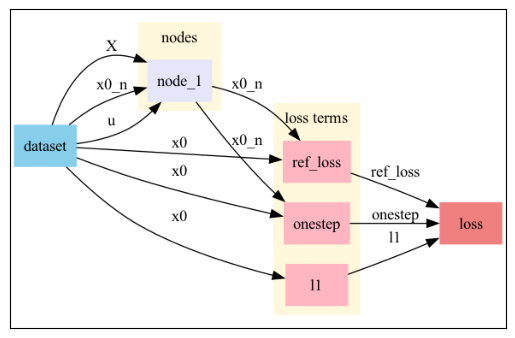


=== Training state x[0] ===
epoch: 0	train_loss: 0.10732	dev_loss: 0.08516	eltime:  0.58494
epoch: 500	train_loss: 0.00008	dev_loss: 0.00005	eltime:  10.94378
epoch: 1000	train_loss: 0.00001	dev_loss: 0.00001	eltime:  22.01219
epoch: 1500	train_loss: 0.00000	dev_loss: 0.00000	eltime:  33.32670

--- Model 0 BEFORE pruning ---
dx0/dt = 0.000*x0 + -0.001*x1 + 0.000*x0^2 + 0.000*x0*x1 + -0.000*x1^2 + 0.076*u_0 + -0.000*u_1 + -0.073*u_0*u_1 + 0.000*x0*u_0 + 0.000*x1*u_0 + -0.000*x0*u_1 + -0.000*x1*u_1 + -0.037*sqrt(x0) + -0.000*sqrt(x1)

   Threshold=5.00e-03, Active=3, Pruned: ['x0', 'x1', 'x0^2', 'x0*x1', 'x1^2', 'u_1', 'x0*u_0', 'x1*u_0', 'x0*u_1', 'x1*u_1', 'sqrt(x1)']
⇒ Active set changed. Adding small noise to retained coefficients.

---------- Model 0 AFTER pruning  ----------
dx0/dt = 0.026*sqrt(x0) + -0.028*u_0 + 0.012*u_0*u_1

epoch: 2000	train_loss: 0.00000	dev_loss: 0.00005	eltime:  44.35924
epoch: 2500	train_loss: 0.00000	dev_loss: 0.00000	eltime:  54.29957
epoch: 3000	train_l

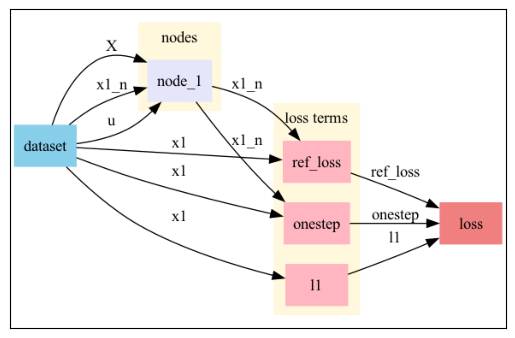


=== Training state x[1] ===
epoch: 0	train_loss: 0.10957	dev_loss: 0.08999	eltime:  320.73766
epoch: 500	train_loss: 0.00007	dev_loss: 0.00004	eltime:  330.93650
epoch: 1000	train_loss: 0.00001	dev_loss: 0.00001	eltime:  341.10429
epoch: 1500	train_loss: 0.00000	dev_loss: 0.00000	eltime:  351.28088

--- Model 0 BEFORE pruning ---
dx1/dt = -0.004*x1 + 0.006*x0 + -0.001*x0^2 + 0.000*x0*x1 + 0.001*x1^2 + 0.003*u_0 + 0.000*u_1 + 0.074*u_0*u_1 + 0.000*x0*u_0 + 0.000*x1*u_0 + 0.000*x0*u_1 + 0.001*x1*u_1 + 0.033*sqrt(x0) + -0.035*sqrt(x1)

   Threshold=5.00e-03, Active=4, Pruned: ['x1', 'x0^2', 'x0*x1', 'x1^2', 'u_0', 'u_1', 'x0*u_0', 'x1*u_0', 'x0*u_1', 'x1*u_1']
⇒ Active set changed. Adding small noise to retained coefficients.

---------- Model 0 AFTER pruning  ----------
dx1/dt = 0.055*x0 + 0.128*sqrt(x0) + 0.152*sqrt(x1) + 0.034*u_0*u_1

epoch: 2000	train_loss: 0.00000	dev_loss: 0.02187	eltime:  361.46765
epoch: 2500	train_loss: 0.00000	dev_loss: 0.00000	eltime:  370.90663
epoch: 3000	t

In [6]:
for i in range(nx):
    # One-element integrator for current state
    integrator_x = OneElementEulerIntegrator(fx_models[i], h=ts)
    integrator_node_x = Node(integrator_x, ['X', f'x{i}_n', 'u'], [f'x{i}_n'], name="x_integrator")
    dynamics_model_x = System([integrator_node_x])
    dynamics_model_x.show()

    x = variable(f"x{i}")
    x_hat = variable(f'x{i}_n')[:, :-1, :]

    # Define losses
    onestep_loss_x = dyn_cfg["onestep_coef"] * ((x_hat[:, 1, :] == x[:, 1, :]) ^ 2)
    onestep_loss_x.name = "onestep_loss"

    reference_loss_x = dyn_cfg["ref_coef"] * ((x_hat == x) ^ 2)
    reference_loss_x.name = "ref_loss"

    # L1 sparsity regularization on model weights
    l1_x = variable([x], lambda x: torch.norm(list(fx_models[i].parameters())[0], p=1))
    loss_l1_x = dyn_cfg["l1_coef"] * (l1_x == 0)
    loss_l1_x.name = "loss_l1"

    # Assemble problem
    objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
    loss_x = PenaltyLoss(objectives_x, [])
    problem_x = Problem([dynamics_model_x], loss_x)
    problem_x.show()

    lr = dyn_cfg["lr"]
    optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

    logger = BasicLogger(
        args=None,
        savedir='test',
        verbosity=500,
        stdout=['dev_loss', 'train_loss']
    )

    trainer_x = SparseTrainer(
        problem=problem_x,
        fx_models=[fx_models[i]],
        lr=lr,
        train_data=None,
        test_data=None,
        optimizers=[optimizer_x],
        epochs=dyn_cfg["epochs"],
        train_metric='train_loss',
        eval_metric='dev_loss',
        logger=logger,
        device=device,
        threshold=dyn_cfg["threshold"],
        prune_every=dyn_cfg["prune_every"],
        warmup=300,
        patience=50,
        threshold_mult=dyn_cfg["threshold_mult"],
        prune_noise=dyn_cfg["prune_noise"],
    )

    for _ in range(1):
        # Regenerate training data for updated horizon
        train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)
        trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
        trainer_x.problem = problem_x

        # Train
        best_model = trainer_x.train()
        trainer_x.model.load_state_dict(best_model)

        # Double prediction steps
        nsteps *= 2
        dynamics_model_x.nsteps = nsteps

In [7]:
# Final SINDy models for each state
for fx in builder.models:
    print(fx)

dx0/dt = -0.039*sqrt(x0) + 0.077*u_0 + -0.077*u_0*u_1

dx1/dt = 0.040*sqrt(x0) + -0.039*sqrt(x1) + 0.079*u_0*u_1



### 📈 Evaluate SINDy Model

Simulates and plots predicted vs. true trajectories using the learned full-state model.


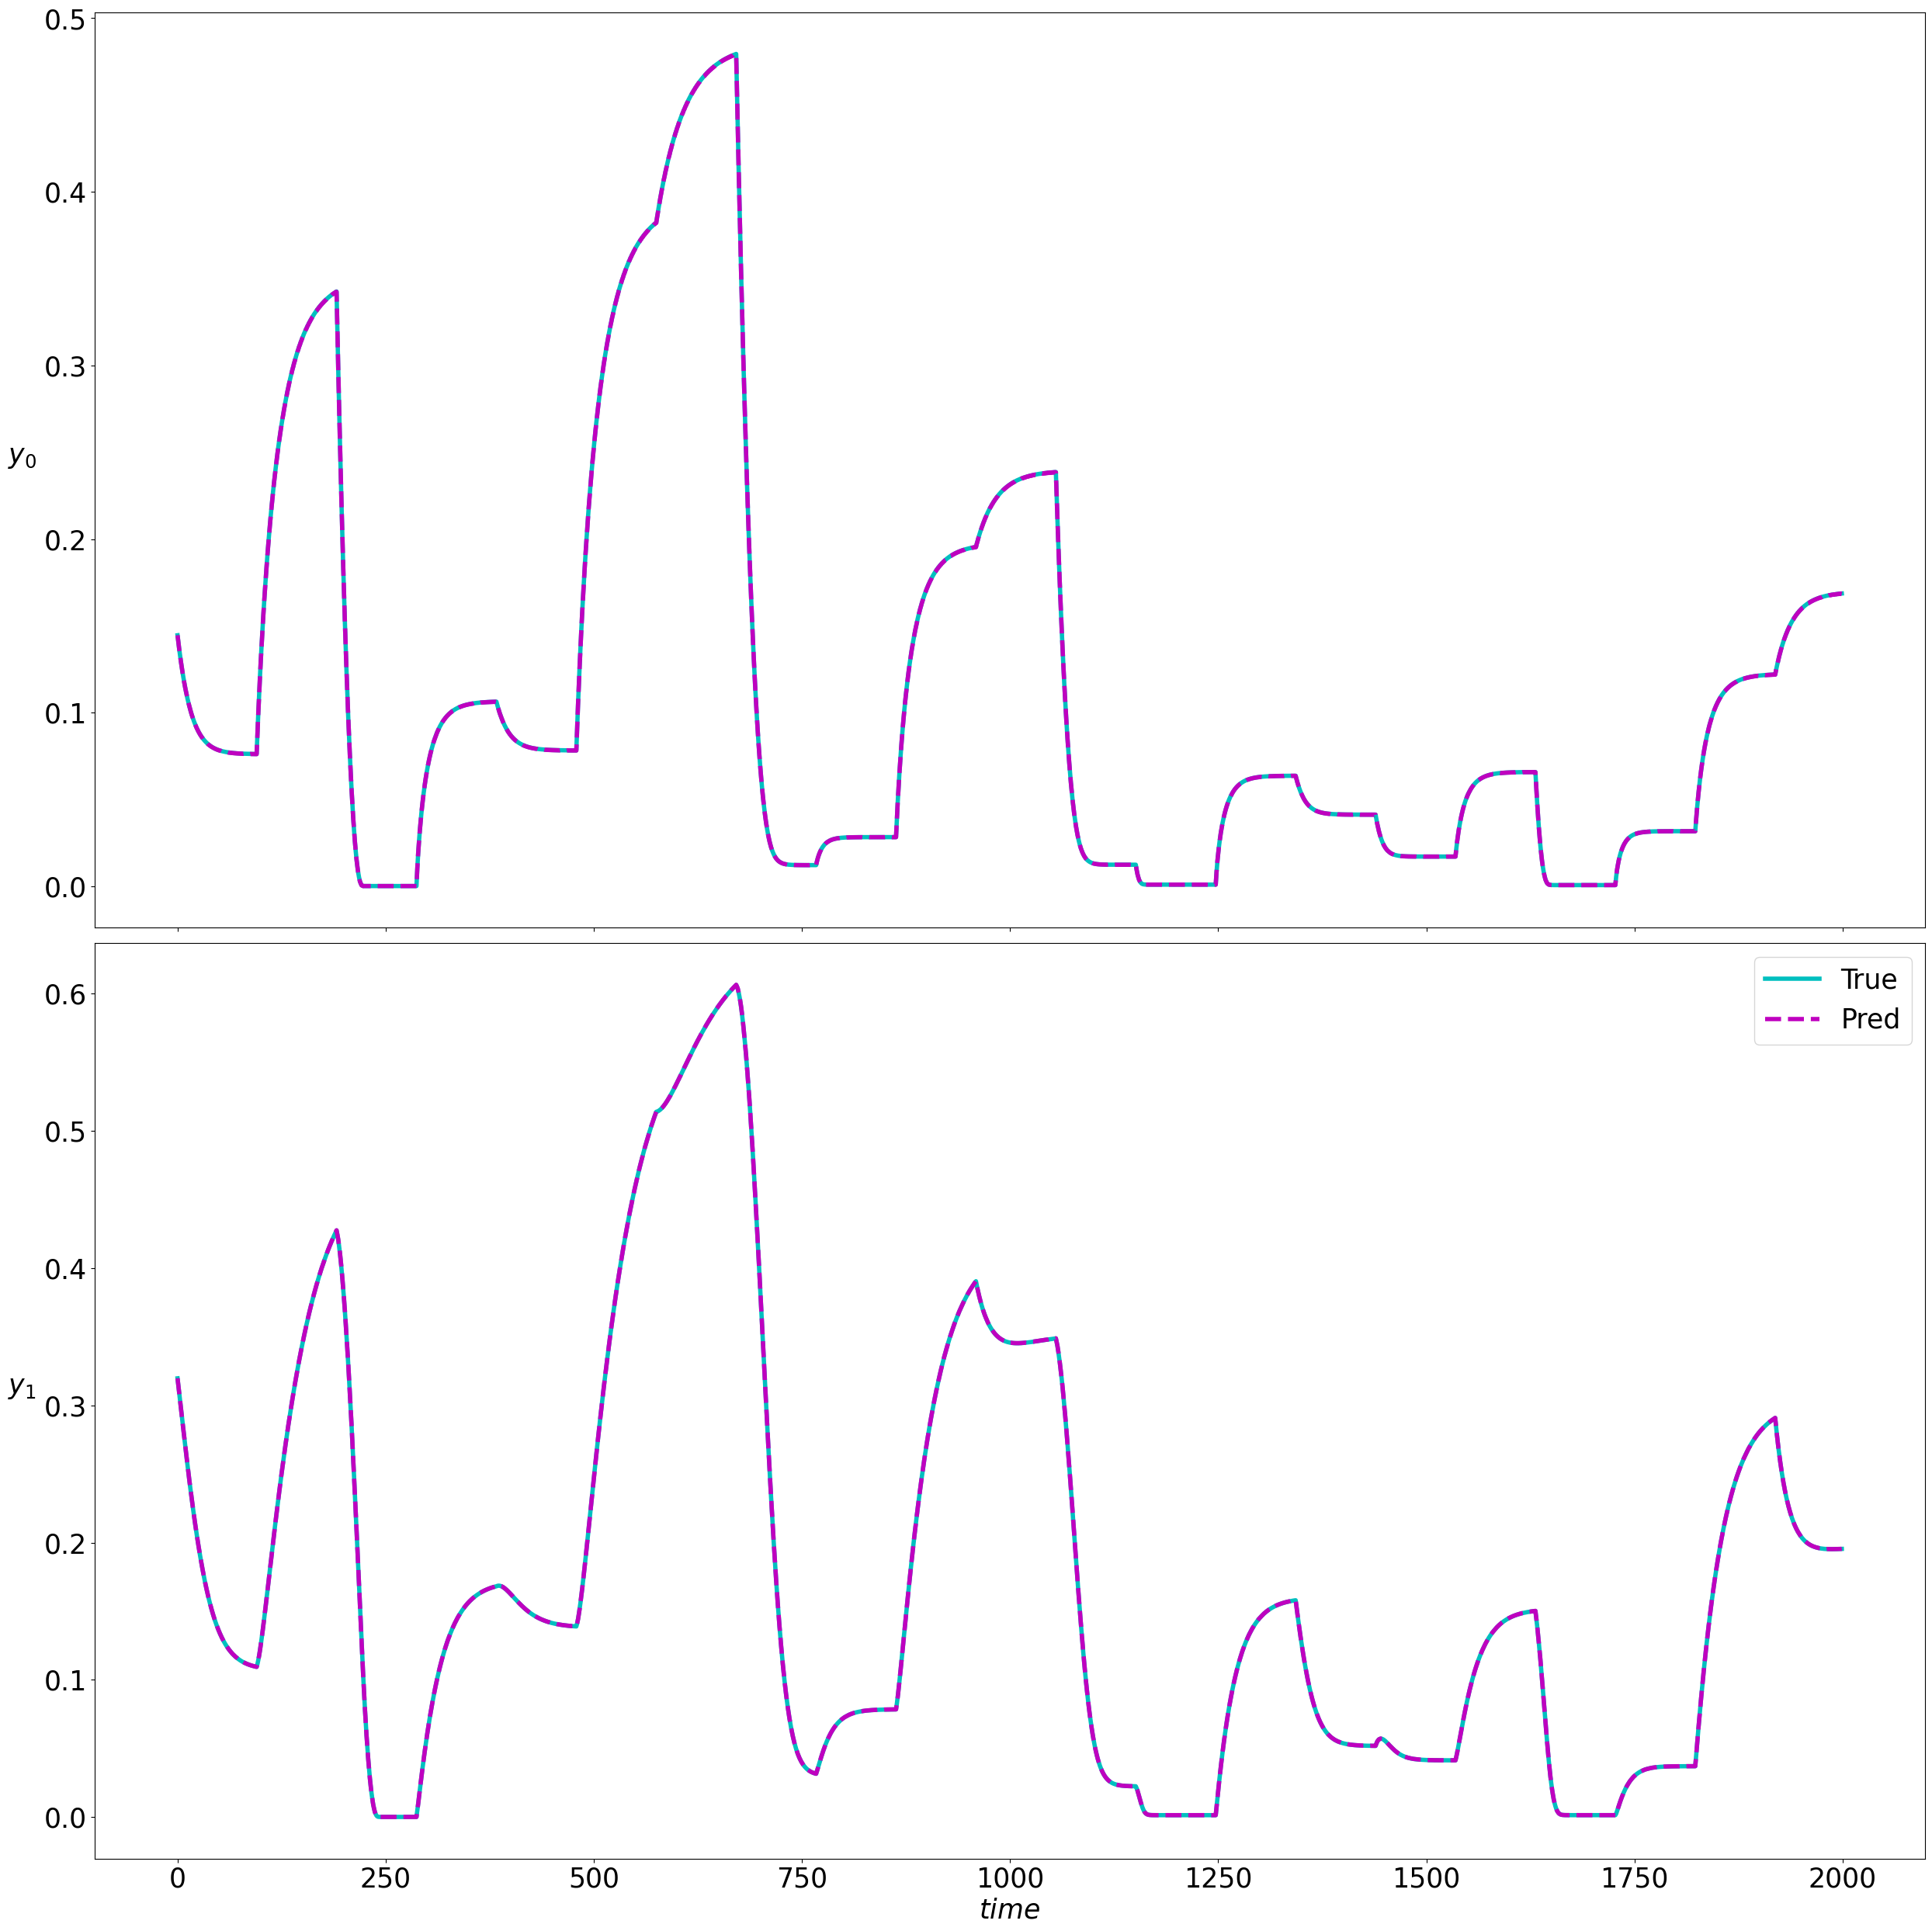

In [8]:
# Full-state integration using all fx_models
integrator_x = FullStateEulerIntegrator(builder.fx_models, ts)
x_integrator_node = Node(integrator_x, ['xn', 'u'], ['xn'], name="x_integrator")

# Create system for evaluation
sindy_system = System([x_integrator_node], nsteps=nsteps)
sindy_system.nsteps = test_data['X'].shape[1]

# Run simulation
test_output = sindy_system(test_data)

# Reshape for plotting
pred_traj = test_output['xn'][:, :-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().numpy().reshape(-1, nx).T

# Plot predicted vs. true trajectories
figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]

for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    axe = ax[row] if nx > 1 else ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)

axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()


#### Save the dynamics model:

In [707]:

# ---------------- user-supplied objects & constants ------------------------ #
base_dir       = "results/tests/dynamics"
# --------------------------------------------------------------------------- #

run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
(Path(run_dir, "run_config.json")
 .write_text(json.dumps(dyn_cfg, indent=4)))

models_dir = run_dir / "saved_models"; models_dir.mkdir()

for i in range(nx):
    # ---- prepare *mapped* model to full library & save .pt ----------
    full_lib   = fx_library(i, nx=nx, nu=nu, seed=0, device=device)

    mapped_pol = map_to_new_fx(fx_models[i], full_lib)
    save_model_with_timestamp(mapped_pol,
                              f"trained_dynamics_x{i}",
                              models_dir)

    # ---- JSON log of the *trained (pruned) dynamics* ------------------
    orig_fx = fx_models[i]
    coef   = orig_fx.coef.detach().cpu().numpy().flatten().tolist()
    fnames = orig_fx.library.function_names
    expr   = str(orig_fx)

    log_entry = {
        "function_names": fnames,
        "coef":           coef,
        "expr":           expr
    }
    with open(run_dir / f"x{i}_log.json", "w") as f:
        json.dump(log_entry, f, indent=2)

print(f"✓  results saved under  {run_dir.as_posix()}")


✅ Model saved to results/tests/dynamics/run_1/saved_models/trained_dynamics_x0_20250809_160941.pth
✅ Model saved to results/tests/dynamics/run_1/saved_models/trained_dynamics_x1_20250809_160941.pth
✓  results saved under  results/tests/dynamics/run_1


## ⚙️ Training the Sparse Dictionary Policy


###  Load Policy Data

Loads the trainig data for control problem


In [683]:
nsteps = 50  # prediction horizon
n_samples = 2000    # number of sampled scenarios
train_loader, dev_loader = get_policy_data(nsteps=nsteps,
                                           n_samples=n_samples,
                                           nx=nx,
                                           xmin=xmin,
                                           xmax=xmax,
                                           zero_refs=False,
                                           same_ref_for_all_states=True,
                                           device=device,
                                           batch_size=200,
                                           seed=5
                                           )
policies_seed = 0

###  Run Policy Training Grid

Trains and saves SINDy policies across multiple `l1_coef` and `threshold` configs with logging and pruning.


In [651]:
# import json
#
# # === Setup ===
# nsteps = 50
# session_id = datetime.now().strftime("%Y%m%d_%H%M%S")
# session_folder = f"results/session_{session_id}"
# os.makedirs(session_folder, exist_ok=True)
#
# # === Base Configuration ===
# base_config = {
#     'reg_coef': 100.0,
#     'l1_coef': 1e-2,
#     'const_coef': 10.0,
#     'lr': 5e-3,
#     'epochs': 3999,
#     'threshold': 0.1,
#     'prune_every': 250,
#     'threshold_mult': 1.1,
# }
# l1_coef_list = [1e-2, 5e-3, 1e-3]
# thresholds = [0.3, 0.2, 0.1, 0.05]
#
# # === Run All Configurations ===
# run_id = 0
# for l1_coef in l1_coef_list:
#     for threshold in thresholds:
#         run_id += 1
#         pol_configs = copy.deepcopy(base_config)
#         pol_configs['threshold'] = threshold
#         pol_configs['run_id'] = run_id
#
#         run_name = f"TwoTank_run{run_id}_l1coef{l1_coef}_th{threshold}"
#         save_dir = os.path.join(session_folder, run_name)
#         os.makedirs(save_dir, exist_ok=True)
#
#         wandb.init(
#             project="sindy-TwoTank-multi-config",
#             name=run_name,
#             config=pol_configs,
#             dir=save_dir,
#             reinit=True,
#         )
#
#         builder = SparsePolicyBuilder(
#             fx_models     = fx_models,
#             is_sindy      = True,
#             gt_model      = None,
#             nx            = nx,
#             nref          = 1,
#             nu            = nu,
#             ts            = ts,
#             nsteps        = nsteps,
#             train_loader  = train_loader,
#             dev_loader    = dev_loader,
#             bounds        = dict(
#                                 xmin=xmin,
#                                 xmax=xmax,
#                                 umin=umin,
#                                 umax=umax
#                             ),
#             config        = pol_configs,
#             seed          = policies_seed,
#             device        = device,
#             logger        = None
#         )
#
#         logger = CustomLogger(
#             args=None,
#             save_dir=save_dir,
#             verbosity=10,
#             stdout=['train_loss', 'dev_loss'],
#             fx_policies=builder.policies,
#             pol_configs=pol_configs
#         )
#
#         builder.set_logger(logger)
#
#         best_state = builder.train()
#
#         # === Save final coefficients
#         for i, fp in enumerate(builder.policies):
#             coef = fp.coef.detach().cpu().numpy()
#             np.savetxt(f"{save_dir}/policy{i}_final.csv", coef, delimiter=",")
#             wandb.log({f"final_active_terms_policy_{i}": int(np.count_nonzero(coef))})
#
#         # === Save mapped models
#         models_dir = os.path.join(save_dir, "saved_models")
#         os.makedirs(models_dir, exist_ok=True)
#
#         for i in range(nu):
#             policy_name = f"u_{i}"
#             policy_base = fx_policy_library(nx=nx, nref=1, policy_name=policy_name, seed=policies_seed, device=device)
#             policy_mapped = map_to_new_fx(builder.policies[i], policy_base)
#             save_model_with_timestamp(policy_mapped, f"trained_policy_{i}", models_dir)
#
#         # Save config
#         with open(os.path.join(save_dir, "run_config.json"), "w") as f:
#             json.dump(pol_configs, f, indent=4)
#
#         wandb.finish()
#
# # === Save session metadata ===
# with open(os.path.join(session_folder, "session_config.txt"), "w") as f:
#     f.write(f"Session ID: {session_id}\n")
#     f.write(f"Started at: {datetime.now()}\n")
#     f.write(f"Total runs: {run_id}\n")
#     f.write(f"L1 Coef List: {l1_coef_list}\n")
#     f.write(f"Thresholds: {thresholds}\n")


###  Train Combined Policy

Trains policy models jointly using a SINDy model with specific configuration


In [652]:
import importlib
import SparseDPC.trainer.problem
import SparseDPC.sindy.sindy
import SparseDPC.sindy.fx_library
importlib.reload(SparseDPC.trainer.problem)
importlib.reload(SparseDPC.sindy.sindy)
importlib.reload(SparseDPC.sindy.fx_library)
from SparseDPC.trainer.problem import SparsePolicyBuilder
from SparseDPC.sindy.sindy import SINDy
from SparseDPC.sindy.fx_library import fx_policy_library

two_tank = ode.TwoTankParam()
two_tank.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)


pol_configs = {
    "reg_coef": 20.0,
    "l1_coef": 0.008,
    "const_coef": 20.0,
    "lr": 0.005,
    "epochs": 5999,
    "threshold": 0.13,
    "prune_every": 600,
    "threshold_mult": 1.17,
    "prune_noise": 0.02
}



None


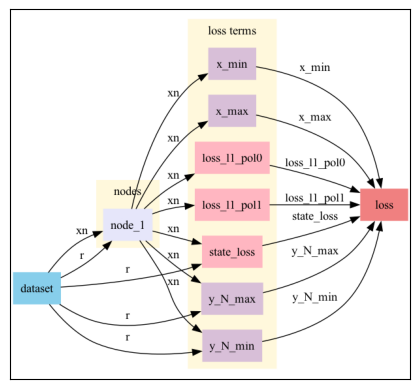

In [653]:
builder_SD_SINDy = SparsePolicyBuilder(
    fx_models     = fx_models,
    is_sindy      = True,
    gt_model      = None,
    nx            = nx,
    nref          = 1,
    nu            = nu,
    ts            = ts,
    nsteps        = nsteps,
    train_loader  = train_loader,
    dev_loader    = dev_loader,
    bounds        = dict(
                        xmin=xmin,
                        xmax=xmax,
                        umin=umin,
                        umax=umax
                    ),
    config        = pol_configs,
    seed          = policies_seed,
    device        = device,
    logger        = BasicLogger(args=None, savedir='runs', verbosity=20,
                                stdout=['dev_loss', 'train_loss'])
)

In [654]:
for fp in builder_SD_SINDy.policies:
    print(fp)

u_0 = -0.001*x_0 + 0.054*sin(x_0) + -0.082*cos(x_0) + -0.074*sin(2*x_0) + -0.039*cos(2*x_0) + 0.027*x_0*sin(x_0) + -0.002*x_0*cos(x_0) + 0.079*x_1 + -0.009*sin(x_1) + 0.026*cos(x_1) + -0.030*sin(2*x_1) + -0.020*cos(2*x_1) + -0.096*x_1*sin(x_1) + -0.066*x_1*cos(x_1) + -0.041*x_0 * x_1 + 0.004*r_0 + 0.040*cos(r_0) + 0.060*sin(r_0) + -0.068*cos(2*r_0) + -0.044*sin(2*r_0) + 0.036*x_0 * r_0 + 0.083*x_0^2 * r_0 + -0.021*x_0 * r_0^2 + 0.075*x_1 * r_0 + -0.016*x_1^2 * r_0 + 0.011*x_1 * r_0^2

u_1 = -0.001*x_0 + 0.054*sin(x_0) + -0.082*cos(x_0) + -0.074*sin(2*x_0) + -0.039*cos(2*x_0) + 0.027*x_0*sin(x_0) + -0.002*x_0*cos(x_0) + 0.079*x_1 + -0.009*sin(x_1) + 0.026*cos(x_1) + -0.030*sin(2*x_1) + -0.020*cos(2*x_1) + -0.096*x_1*sin(x_1) + -0.066*x_1*cos(x_1) + -0.041*x_0 * x_1 + 0.004*r_0 + 0.040*cos(r_0) + 0.060*sin(r_0) + -0.068*cos(2*r_0) + -0.044*sin(2*r_0) + 0.036*x_0 * r_0 + 0.083*x_0^2 * r_0 + -0.021*x_0 * r_0^2 + 0.075*x_1 * r_0 + -0.016*x_1^2 * r_0 + 0.011*x_1 * r_0^2



In [655]:
builder_SD_SINDy.train()


epoch: 0	train_loss: 6.24039	dev_loss: 7.86002	eltime:  4.90227
epoch: 20	train_loss: 1.12408	dev_loss: 1.15757	eltime:  59.42944
epoch: 40	train_loss: 1.02969	dev_loss: 1.04268	eltime:  112.96051
epoch: 60	train_loss: 0.99487	dev_loss: 0.99897	eltime:  165.03050
epoch: 80	train_loss: 0.97749	dev_loss: 0.97709	eltime:  216.89833
epoch: 100	train_loss: 0.96723	dev_loss: 0.96402	eltime:  269.96392
epoch: 120	train_loss: 0.96048	dev_loss: 0.95510	eltime:  322.31747
epoch: 140	train_loss: 0.95624	dev_loss: 0.94969	eltime:  375.60537
epoch: 160	train_loss: 0.95244	dev_loss: 0.94485	eltime:  430.82451
epoch: 180	train_loss: 0.94985	dev_loss: 0.94172	eltime:  484.52190
epoch: 200	train_loss: 0.94723	dev_loss: 0.93823	eltime:  536.56305
epoch: 220	train_loss: 0.94453	dev_loss: 0.93555	eltime:  588.12609
epoch: 240	train_loss: 0.94246	dev_loss: 0.93343	eltime:  640.38605
epoch: 260	train_loss: 0.94093	dev_loss: 0.93154	eltime:  692.55203
epoch: 280	train_loss: 0.93963	dev_loss: 0.93013	eltime: 

{}

None


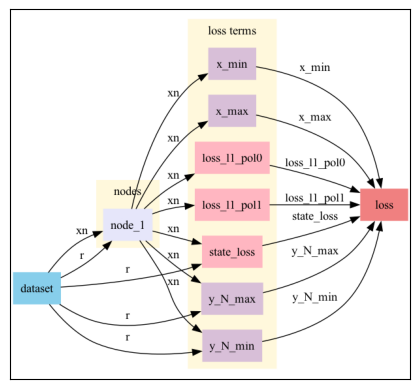

In [668]:
builder_SD_WB = SparsePolicyBuilder(
    fx_models     = fx_models,
    is_sindy      = False,
    gt_model      = two_tank,
    nx            = nx,
    nref          = 1,
    nu            = nu,
    ts            = ts,
    nsteps        = nsteps,
    train_loader  = train_loader,
    dev_loader    = dev_loader,
    bounds        = dict(
                        xmin=xmin,
                        xmax=xmax,
                        umin=umin,
                        umax=umax
                    ),
    config        = pol_configs,
    seed          = policies_seed,
    device        = device,
    logger        = BasicLogger(args=None, savedir='runs', verbosity=20,
                                stdout=['dev_loss', 'train_loss'])
)

In [669]:
builder_SD_WB.train()


epoch: 0	train_loss: 6.32104	dev_loss: 7.85030	eltime:  2.32296
epoch: 20	train_loss: 1.06545	dev_loss: 1.10021	eltime:  28.95541
epoch: 40	train_loss: 0.97284	dev_loss: 0.98873	eltime:  60.85663
epoch: 60	train_loss: 0.93951	dev_loss: 0.94661	eltime:  91.97689
epoch: 80	train_loss: 0.92309	dev_loss: 0.92567	eltime:  123.43815
epoch: 100	train_loss: 0.91384	dev_loss: 0.91431	eltime:  155.13207
epoch: 120	train_loss: 0.90794	dev_loss: 0.90656	eltime:  187.03501
epoch: 140	train_loss: 0.90354	dev_loss: 0.90144	eltime:  219.38467
epoch: 160	train_loss: 0.89960	dev_loss: 0.89695	eltime:  251.45497
epoch: 180	train_loss: 0.89737	dev_loss: 0.89400	eltime:  284.17317
epoch: 200	train_loss: 0.89553	dev_loss: 0.89138	eltime:  316.81513
epoch: 220	train_loss: 0.89298	dev_loss: 0.88940	eltime:  349.62780
epoch: 240	train_loss: 0.89080	dev_loss: 0.88728	eltime:  382.95354
epoch: 260	train_loss: 0.88924	dev_loss: 0.88567	eltime:  416.95265
epoch: 280	train_loss: 0.88794	dev_loss: 0.88423	eltime:  4

{'nodes.0.nodes.1.callable.block.c1': tensor(0.0800),
 'nodes.0.nodes.1.callable.block.c2': tensor(0.0400)}

In [671]:
print("############## Policy trained on SINDy Dynamics ################")
for fp in builder_SD_SINDy.policies:
    print(fp)

print("############## Policy trained on White-Box Dynamics ################")

for fp in builder_SD_WB.policies:
    print(fp)



############## Policy trained on SINDy Dynamics ################
u_0 = 1.553*cos(2*x_0) + 2.213*cos(2*x_1) + -3.687*cos(2*r_0) + 0.454*sin(2*r_0)

u_1 = 1.146*cos(2*x_1) + -1.136*cos(2*x_0)

############## Policy trained on White-Box Dynamics ################
u_0 = 1.334*cos(2*x_0) + 1.941*cos(2*x_1) + -3.204*cos(2*r_0) + 0.451*sin(2*r_0)

u_1 = 1.164*cos(2*x_1) + -1.157*cos(2*x_0)



In [672]:
# --------------------------------------------------------------------------- #
# INLINE SNAPSHOT (mapped .pt + raw-policy JSON)
# --------------------------------------------------------------------------- #
import os, json, numpy as np, torch
from pathlib import Path
from SparseDPC.sindy.fx_library import fx_policy_library
from SparseDPC.utils.utils       import map_to_new_fx, save_model_with_timestamp

# ---------------- user-supplied objects & constants ------------------------ #
builders       = {"WB": builder_SD_WB, "SINDy": builder_SD_SINDy}   # tag → builder
base_dir       = "results/tests/sparse"
# --------------------------------------------------------------------------- #

# 1. auto-increment parent run directory
run_id  = 1
while Path(base_dir, f"run_{run_id}").exists():
    run_id += 1
run_dir = Path(base_dir, f"run_{run_id}");  run_dir.mkdir(parents=True)
(Path(run_dir, "run_config.json")
 .write_text(json.dumps(pol_configs, indent=4)))

# 2. iterate over builders
for tag, bld in builders.items():
    tag_dir    = run_dir / tag;          tag_dir.mkdir()
    models_dir = tag_dir / "saved_models"; models_dir.mkdir()

    for i in range(nu):
        # ---- prepare *mapped* model to full library & save .pt ----------
        full_lib   = fx_policy_library(nx=nx, nref=1,
                                       policy_name=f"u_{i}",
                                       seed=policies_seed,
                                       device=bld.device)
        mapped_pol = map_to_new_fx(bld.policies[i], full_lib)
        save_model_with_timestamp(mapped_pol,
                                  f"trained_policy_{i}",
                                  models_dir)

        # ---- JSON log of the *trained (pruned) policy* ------------------
        orig_pol = bld.policies[i]
        coef   = orig_pol.coef.detach().cpu().numpy().flatten().tolist()
        fnames = orig_pol.library.function_names
        expr   = str(orig_pol)

        log_entry = {
            "function_names": fnames,
            "coef":           coef,
            "active_terms":   int(np.count_nonzero(coef)),
            "expr":           expr
        }
        with open(tag_dir / f"policy{i}_log.json", "w") as f:
            json.dump(log_entry, f, indent=2)

print(f"✓  results saved under  {run_dir.as_posix()}")


✅ Model saved to results/tests/run_3/WB/saved_models/trained_policy_0_20250808_150421.pth
✅ Model saved to results/tests/run_3/WB/saved_models/trained_policy_1_20250808_150421.pth
✅ Model saved to results/tests/run_3/SINDy/saved_models/trained_policy_0_20250808_150421.pth
✅ Model saved to results/tests/run_3/SINDy/saved_models/trained_policy_1_20250808_150421.pth
✓  results saved under  results/tests/run_3


###  Closed-Loop Rollout (White-Box)

Simulates the learned policy in closed-loop using a ground-truth white-box ODE model.


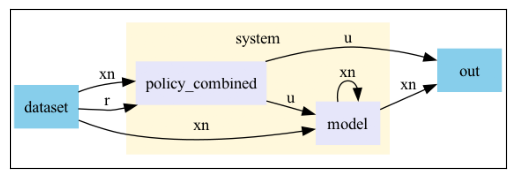

(<Figure size 2000x1600 with 2 Axes>,
 array([[<Axes: xlabel='Time', ylabel='y'>],
        [<Axes: xlabel='Time', ylabel='u'>]], dtype=object))

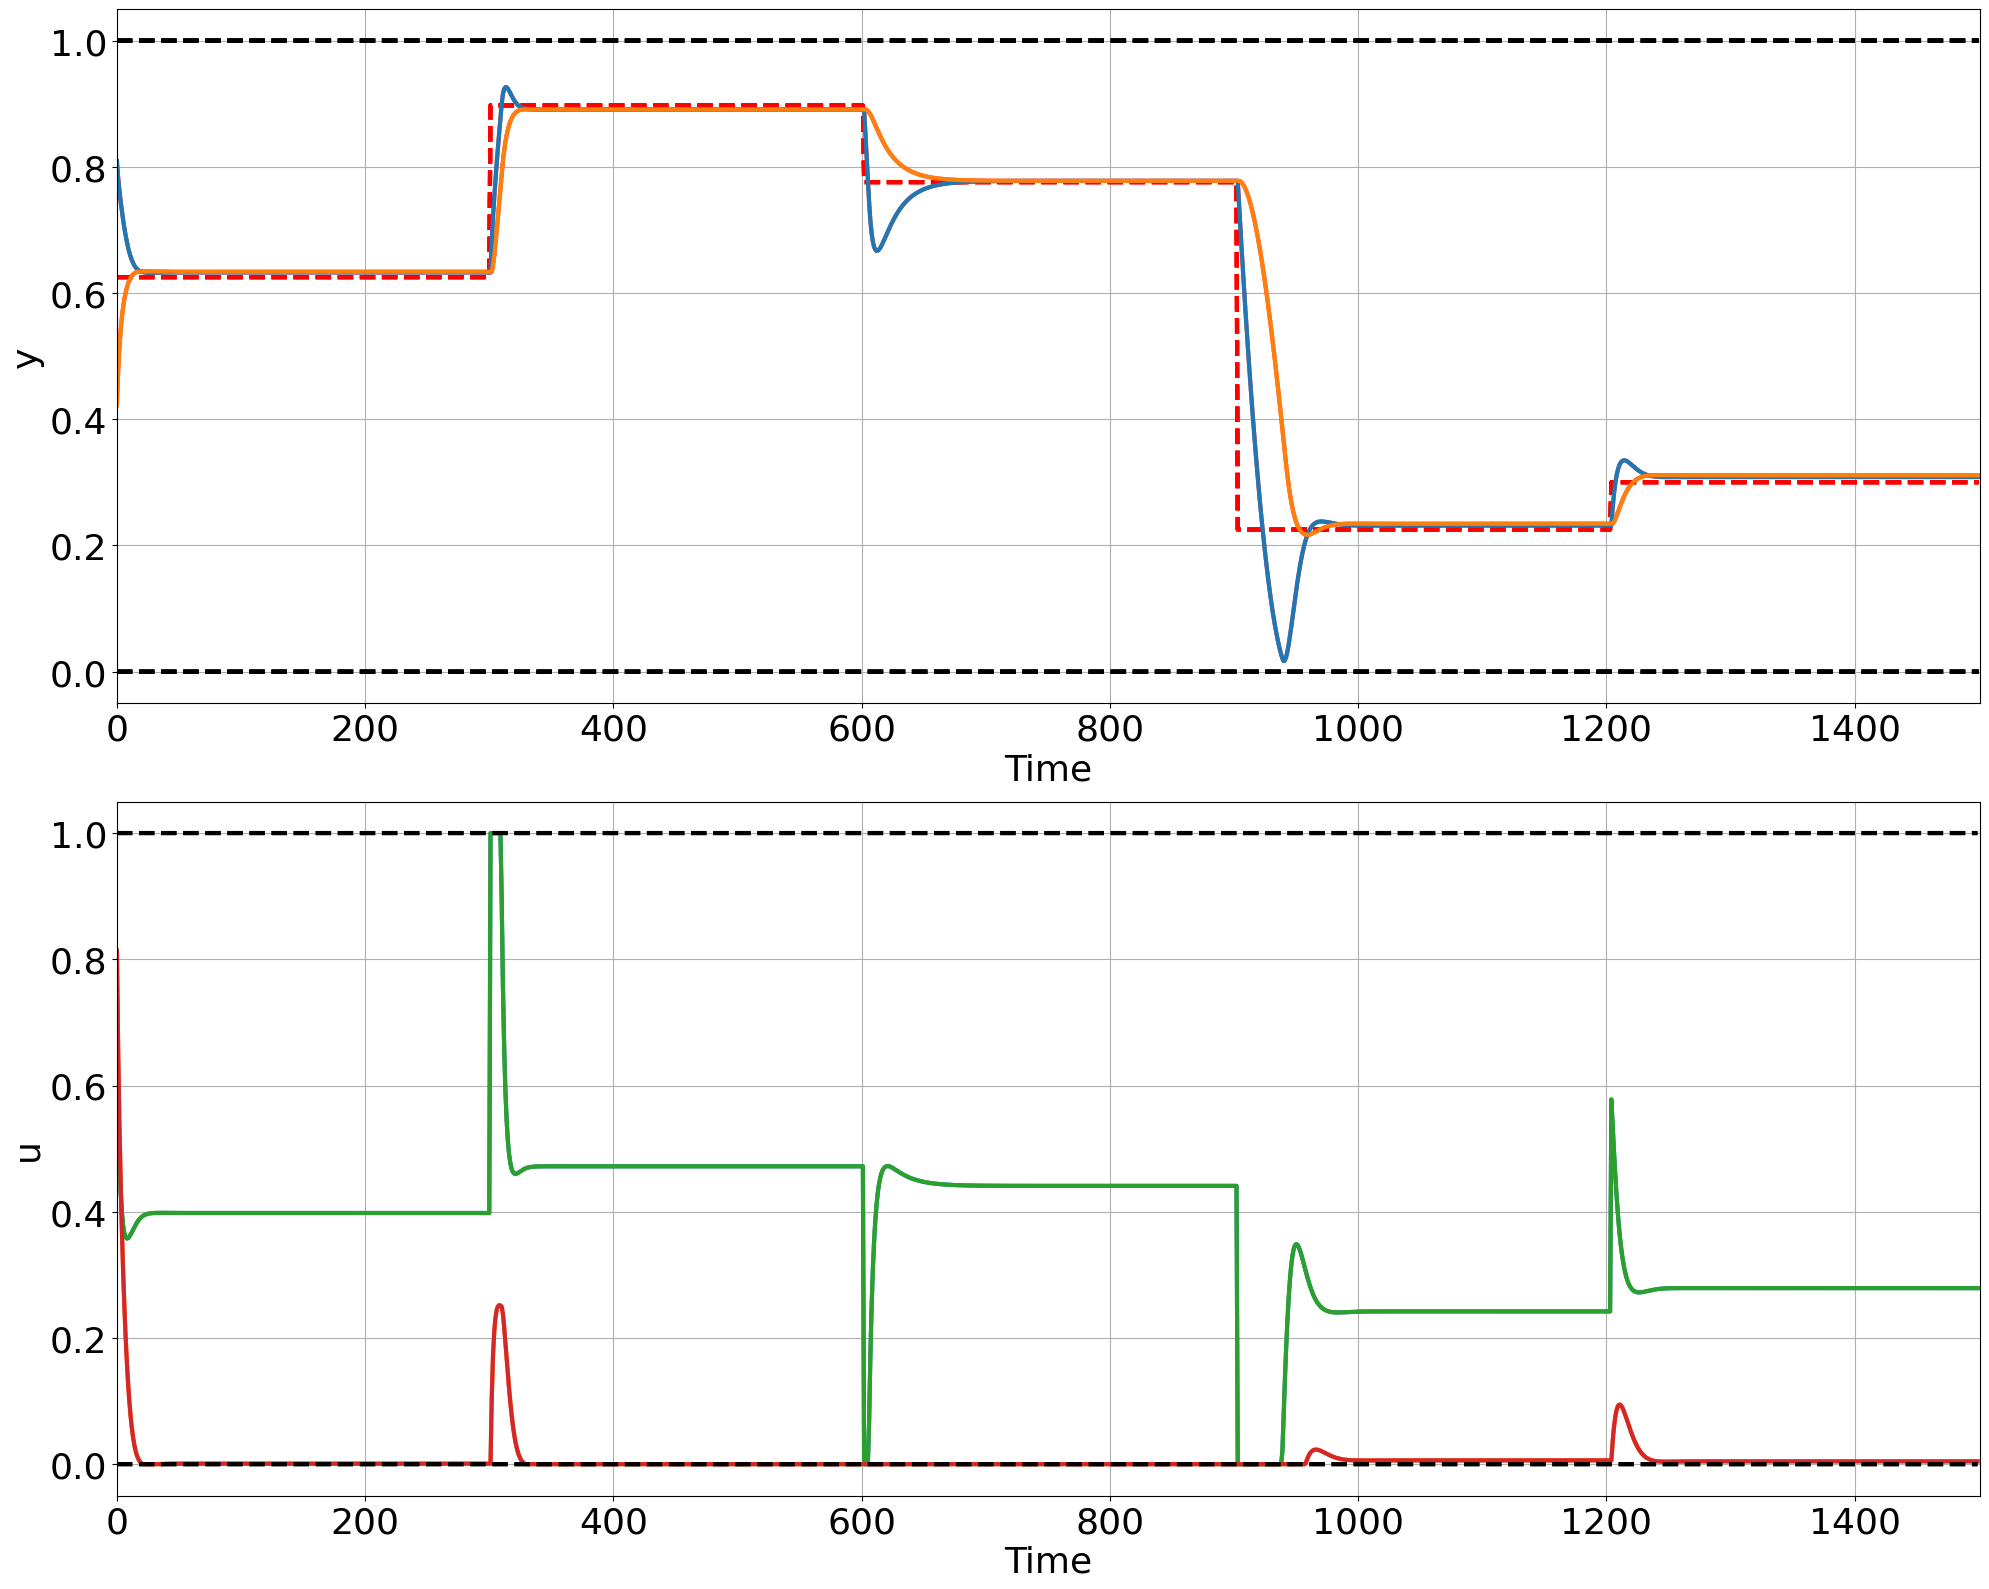

In [698]:
# White-box ODE model (ground truth)
two_tank = ode.TwoTankParam()
two_tank.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)

# Euler integrator for ODE system
gt_integrator = integrators.Euler(two_tank, h=torch.tensor(ts))
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

policy_node = Node(
            lambda xn, r: torch.cat(
                [torch.clamp(fp(xn, r), umin, umax) for fp in builder_SD_SINDy.policies],
                dim=-1
            ),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )
# Compose symbolic closed-loop system: policy + true plant
gt_sindy_policy = copy.deepcopy(System([policy_node, gt_integrator_node]))
gt_sindy_policy.show()

# Closed-loop simulation setup
nsteps_test = 1500
torch.manual_seed(63)
seed = 7

rng = np.random.default_rng(seed)

# Step reference signal (same across both states)
np_refs = psl.signals.step(nsteps_test+1, 1, min=xmin, max=xmax, randsteps=5, rng=rng)
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps_test+1, 1)
torch_ref = torch.cat([R, R], dim=-1)

# Random initial state
x_sample = torch.rand(1, 1, nx, dtype=torch.float32)
data = {
    'xn': x_sample,
    'x0_n': x_sample[:, :, 0:1],
    'x1_n': x_sample[:, :, 1:2],
    'r': torch_ref
}

# Simulate system
gt_sindy_policy.nsteps = nsteps_test
trajectories = gt_sindy_policy(data)

# Constraint bounds for plotting
Umin = umin * np.ones([nsteps_test, nu])
Umax = umax * np.ones([nsteps_test, nu])
Xmin = xmin * np.ones([nsteps_test+1, nx])
Xmax = xmax * np.ones([nsteps_test+1, nx])

# Plot trajectories
pltCL(
    Y=trajectories['xn'].detach().cpu().reshape(nsteps_test + 1, nx),
    R=trajectories['r'].detach().cpu().reshape(nsteps_test + 1, nref),
    U=trajectories['u'].detach().cpu().reshape(nsteps_test, nu),
    Umin=Umin, Umax=Umax,
    Ymin=Xmin, Ymax=Xmax
)


### Training Neural Network Policies


In [708]:
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations
from neuromancer.trainer import Trainer
import time

In [709]:
nn_config = {
    "layers": [32, 32],
    "reg_coef": 20.0,
    "const_coef": 20.0,
    "lr": 0.005,
    "epochs": 1000,
    "warmup": 100,
    "patience": 50,
}

#### On SINDy Dynamics

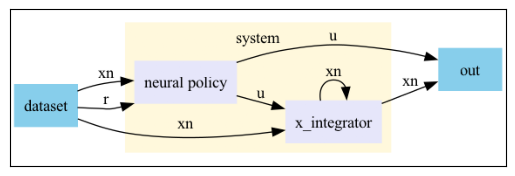

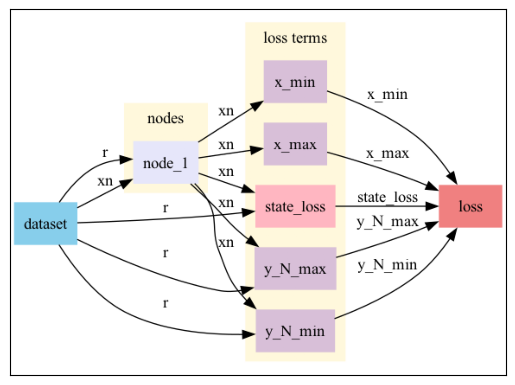

None
Number of parameters: 1282
************   training with 50 steps   ************   
epoch: 0	train_loss: 9.15315	dev_loss: 9.31639	eltime:  0.53623
epoch: 20	train_loss: 1.31036	dev_loss: 1.33651	eltime:  10.60304
epoch: 40	train_loss: 0.98602	dev_loss: 1.01935	eltime:  22.48467
epoch: 60	train_loss: 0.92781	dev_loss: 0.93758	eltime:  33.22379
epoch: 80	train_loss: 0.89549	dev_loss: 0.89141	eltime:  44.24742
epoch: 100	train_loss: 0.87291	dev_loss: 0.86732	eltime:  55.54326
epoch: 120	train_loss: 0.86002	dev_loss: 0.85225	eltime:  66.95163
epoch: 140	train_loss: 0.85146	dev_loss: 0.84248	eltime:  78.35189
epoch: 160	train_loss: 0.84612	dev_loss: 0.83742	eltime:  89.90960
epoch: 180	train_loss: 0.84130	dev_loss: 0.82987	eltime:  101.52039
epoch: 200	train_loss: 0.84335	dev_loss: 0.82841	eltime:  113.54397
epoch: 220	train_loss: 0.83638	dev_loss: 0.82445	eltime:  125.20124
epoch: 240	train_loss: 0.83597	dev_loss: 0.82381	eltime:  137.02931
epoch: 260	train_loss: 0.83270	dev_loss: 0.8

In [688]:
# neural net control policy with hard control action bounds
net_sindy = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=nn_config["layers"],
                    nonlin=activations['gelu'], min=umin, max=umax)
policy_neural_sindy = Node(net_sindy, ['xn', 'r'], ['u'], name='neural policy')

integ = FullStateEulerIntegrator(fx_models, ts)
integ_node = Node(integ, ['xn', 'u'], ['xn'], name="x_integrator")

neural_sindy_system = System([policy_neural_sindy, integ_node ], nsteps=nsteps)
neural_sindy_system.show()

# variables
x = variable('xn')
ref = variable('r')
# objectives
regulation_loss = nn_config['reg_coef'] * ((x == ref) ^ 2)  # target posistion
# constraints
state_lower_bound_penalty = nn_config['const_coef'] *(x > xmin)
state_upper_bound_penalty = nn_config['const_coef'] *(x < xmax)
terminal_lower_bound_penalty = nn_config['const_coef'] *(x[:, [-1], :] > ref-0.01)
terminal_upper_bound_penalty = nn_config['const_coef'] *(x[:, [-1], :] < ref+0.01)
# objectives and constraints names for nicer plot
regulation_loss.name = 'state_loss'
state_lower_bound_penalty.name = 'x_min'
state_upper_bound_penalty.name = 'x_max'
terminal_lower_bound_penalty.name = 'y_N_min'
terminal_upper_bound_penalty.name = 'y_N_max'
# list of constraints and objectives
objectives = [regulation_loss]
constraints = [
    state_lower_bound_penalty,
    state_upper_bound_penalty,
    terminal_lower_bound_penalty,
    terminal_upper_bound_penalty,
]

# data (x_k, r_k) -> parameters (xi_k) -> policy (u_k) -> dynamics (x_k+1)
components = [neural_sindy_system]
# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints)
# construct constrained optimization problem
problem = Problem(components, loss)
# plot computational graph
problem.show()

optimizer = torch.optim.AdamW(policy_neural_sindy.parameters(), lr=0.002)
logger_NN_SINDy = BasicLogger(args=None, savedir='test', verbosity=20,
                        stdout=['dev_loss', 'train_loss'])
#  Neuromancer trainer
trainer = Trainer(
    problem,
    None,
    None,
    optimizer=optimizer,
    epochs=nn_config["epochs"],
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=nn_config["warmup"],
    patience=nn_config["patience"],
    logger=logger_NN_SINDy
)

print(f'************   training with {nsteps} steps   ************   ')
trainer.train_data, trainer.dev_data = train_loader, dev_loader
trainer.problem = problem
start_time = time.time()

# Train control policy
best_model = trainer.train()

# load best trained model
end_time = time.time()
total_time_NN_SINDy = end_time - start_time

print("Total Training time: ", total_time_NN_SINDy)

#### On White-Box Model:

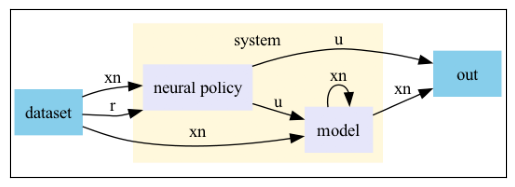

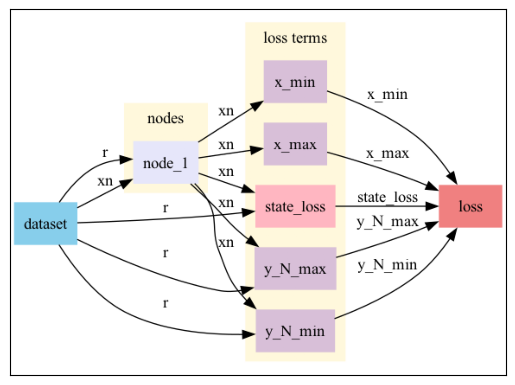

None
Number of parameters: 1282
************   training with 50 steps   ************   
epoch: 0	train_loss: 10.80332	dev_loss: 10.57163	eltime:  0.57164
epoch: 20	train_loss: 1.19860	dev_loss: 1.23995	eltime:  11.92084
epoch: 40	train_loss: 0.91916	dev_loss: 0.95414	eltime:  23.04591
epoch: 60	train_loss: 0.87085	dev_loss: 0.88897	eltime:  34.08604
epoch: 80	train_loss: 0.84268	dev_loss: 0.84760	eltime:  45.14254
epoch: 100	train_loss: 0.82343	dev_loss: 0.82245	eltime:  56.09852
epoch: 120	train_loss: 0.81100	dev_loss: 0.80736	eltime:  67.15353
epoch: 140	train_loss: 0.80344	dev_loss: 0.79921	eltime:  78.09911
epoch: 160	train_loss: 0.79862	dev_loss: 0.79359	eltime:  89.07108
epoch: 180	train_loss: 0.79561	dev_loss: 0.78979	eltime:  99.92957
epoch: 200	train_loss: 0.79386	dev_loss: 0.78876	eltime:  110.88691
epoch: 220	train_loss: 0.78989	dev_loss: 0.78496	eltime:  122.13690
epoch: 240	train_loss: 0.78867	dev_loss: 0.78350	eltime:  133.66995
epoch: 260	train_loss: 0.78811	dev_loss: 0.

In [689]:
# neural net control policy with hard control action bounds
net_WB = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=nn_config["layers"],
                    nonlin=activations['gelu'], min=umin, max=umax)
policy_neural_WB = Node(net_WB, ['xn', 'r'], ['u'], name='neural policy')

neural_WB_system = System([policy_neural_WB, gt_integrator_node ], nsteps=nsteps)
neural_WB_system.show()

# variables
x = variable('xn')
ref = variable('r')
# objectives
regulation_loss = nn_config['reg_coef'] * ((x == ref) ^ 2)  # target posistion
# constraints
state_lower_bound_penalty = nn_config['const_coef'] *(x > xmin)
state_upper_bound_penalty = nn_config['const_coef'] *(x < xmax)
terminal_lower_bound_penalty = nn_config['const_coef'] *(x[:, [-1], :] > ref-0.01)
terminal_upper_bound_penalty = nn_config['const_coef'] *(x[:, [-1], :] < ref+0.01)
# objectives and constraints names for nicer plot
regulation_loss.name = 'state_loss'
state_lower_bound_penalty.name = 'x_min'
state_upper_bound_penalty.name = 'x_max'
terminal_lower_bound_penalty.name = 'y_N_min'
terminal_upper_bound_penalty.name = 'y_N_max'
# list of constraints and objectives
objectives = [regulation_loss]
constraints = [
    state_lower_bound_penalty,
    state_upper_bound_penalty,
    terminal_lower_bound_penalty,
    terminal_upper_bound_penalty,
]

# data (x_k, r_k) -> parameters (xi_k) -> policy (u_k) -> dynamics (x_k+1)
components = [neural_WB_system]
# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints)
# construct constrained optimization problem
problem = Problem(components, loss)
# plot computational graph
problem.show()

optimizer = torch.optim.AdamW(policy_neural_WB.parameters(), lr=0.002)
logger_NN_WB = BasicLogger(args=None, savedir='test', verbosity=20,
                        stdout=['dev_loss', 'train_loss'])
#  Neuromancer trainer
trainer = Trainer(
    problem,
    None,
    None,
    optimizer=optimizer,
    epochs=nn_config["epochs"],
    train_metric='train_loss',
    eval_metric='dev_loss',
    warmup=nn_config["warmup"],
    patience=nn_config["patience"],
    logger=logger_NN_WB
)

print(f'************   training with {nsteps} steps   ************   ')
trainer.train_data, trainer.dev_data = train_loader, dev_loader
trainer.problem = problem
start_time = time.time()

# Train control policy
best_model = trainer.train()

# load best trained model
end_time = time.time()
total_time_NN_WB = end_time - start_time

print("Total Training time: ", total_time_NN_WB)

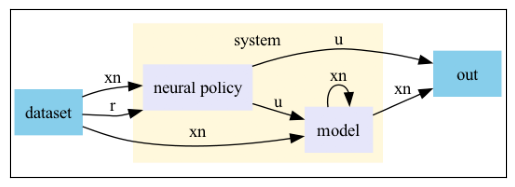

(<Figure size 2000x1600 with 2 Axes>,
 array([[<Axes: xlabel='Time', ylabel='y'>],
        [<Axes: xlabel='Time', ylabel='u'>]], dtype=object))

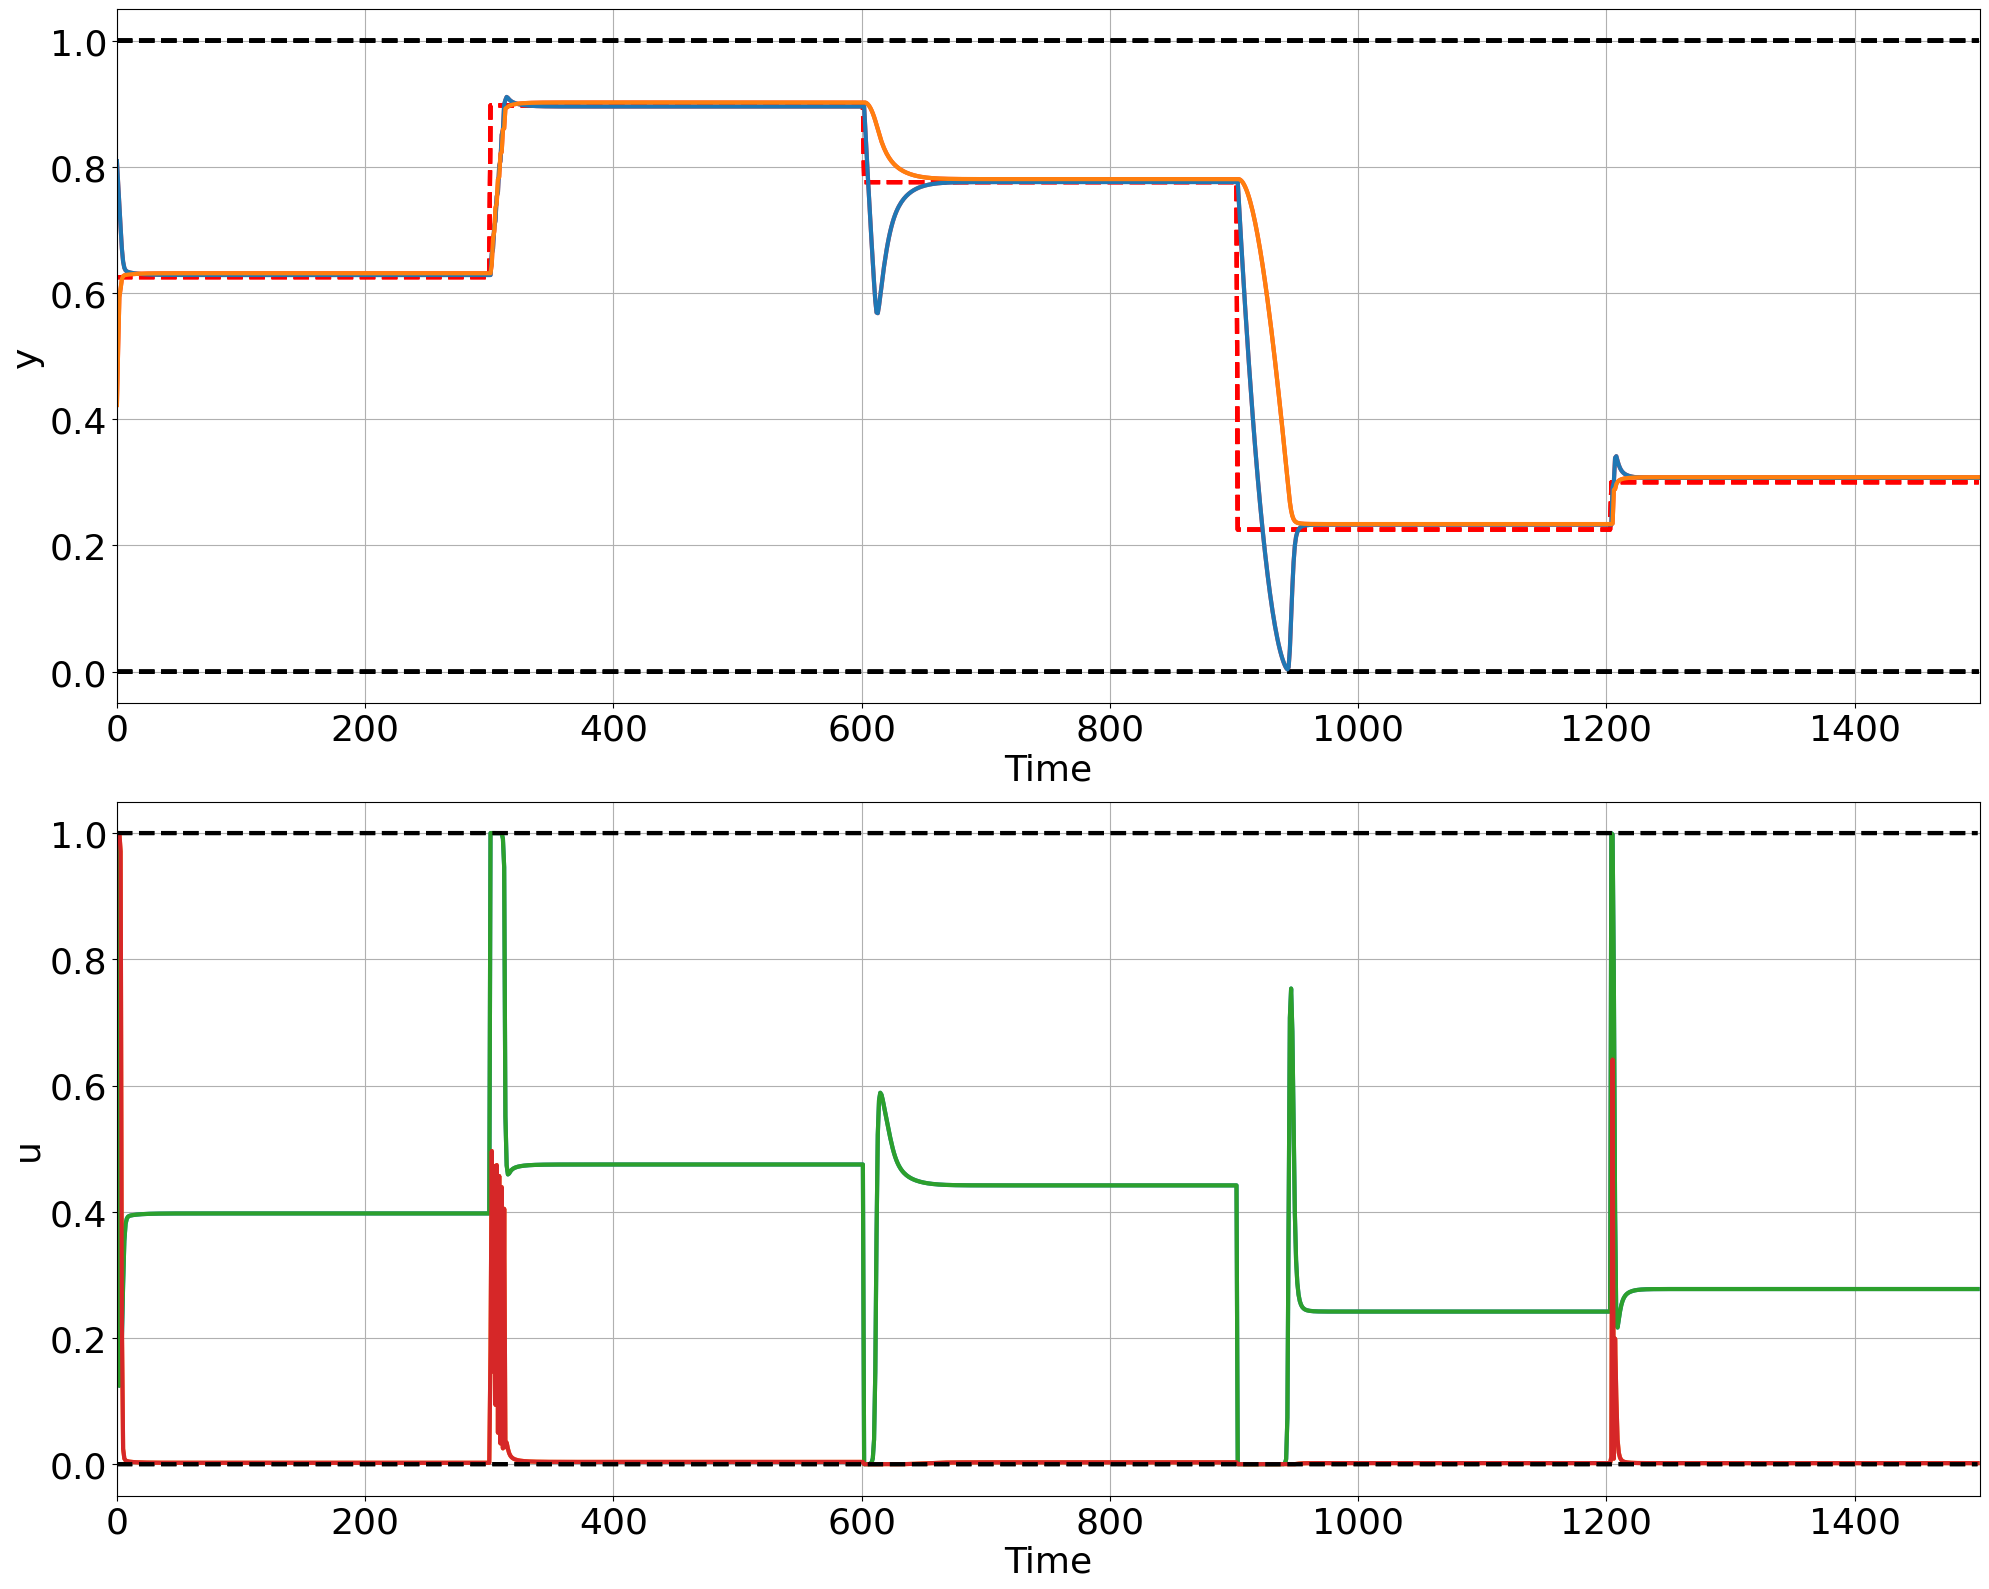

In [696]:
# White-box ODE model (ground truth)
two_tank = ode.TwoTankParam()
two_tank.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)

# Euler integrator for ODE system
gt_integrator = integrators.Euler(two_tank, h=torch.tensor(ts))
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

# Compose symbolic closed-loop system: policy + true plant
gt_sindy_policy = copy.deepcopy(System([policy_neural_sindy, gt_integrator_node]))
gt_sindy_policy.show()

# Closed-loop simulation setup
nsteps_test = 1500
torch.manual_seed(63)
seed = 7

rng = np.random.default_rng(seed)

# Step reference signal (same across both states)
np_refs = psl.signals.step(nsteps_test+1, 1, min=xmin, max=xmax, randsteps=5, rng=rng)
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps_test+1, 1)
torch_ref = torch.cat([R, R], dim=-1)

# Random initial state
x_sample = torch.rand(1, 1, nx, dtype=torch.float32)
data = {
    'xn': x_sample,
    'x0_n': x_sample[:, :, 0:1],
    'x1_n': x_sample[:, :, 1:2],
    'r': torch_ref
}

# Simulate system
gt_sindy_policy.nsteps = nsteps_test
trajectories = gt_sindy_policy(data)

# Constraint bounds for plotting
Umin = umin * np.ones([nsteps_test, nu])
Umax = umax * np.ones([nsteps_test, nu])
Xmin = xmin * np.ones([nsteps_test+1, nx])
Xmax = xmax * np.ones([nsteps_test+1, nx])

# Plot trajectories
pltCL(
    Y=trajectories['xn'].detach().cpu().reshape(nsteps_test + 1, nx),
    R=trajectories['r'].detach().cpu().reshape(nsteps_test + 1, nref),
    U=trajectories['u'].detach().cpu().reshape(nsteps_test, nu),
    Umin=Umin, Umax=Umax,
    Ymin=Xmin, Ymax=Xmax
)


#### Save the models

In [706]:
# Output directory
save_dir = "results/tests/neural"
os.makedirs(save_dir, exist_ok=True)

# Save the state_dict of each policy
torch.save(policy_neural_sindy.state_dict(), os.path.join(save_dir, "policy_neural_sindy.pth"))
torch.save(policy_neural_WB.state_dict(), os.path.join(save_dir, "policy_neural_WB.pth"))

# Save the nn_config as JSON
with open(os.path.join(save_dir, "nn_config.json"), "w") as f:
    json.dump(nn_config, f, indent=4)